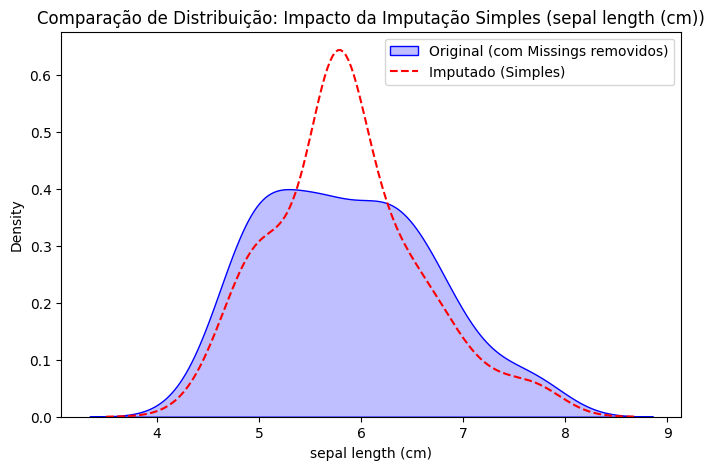

In [24]:
from sklearn.impute import SimpleImputer
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando uma base de teste do sklearn
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target_names[data.target]

# Criando alguns dados missing artificialmente (20% dos dados)
np.random.seed(42)
mask_num = np.random.rand(*df.iloc[:, :-1].shape) < 0.2
df.iloc[:, :-1] = df.iloc[:, :-1].mask(mask_num)

mask_cat = np.random.rand(df.shape[0]) < 0.2
df.loc[mask_cat, 'target'] = np.nan

# Salvando uma cópia antes da imputação para o gráfico KDE
df_missing_pre = df.copy()

# Exemplo de imputação simples para baseline
# Estratégia de mediana para numéricos e moda para categóricos
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

# Aplicando imputação
colunas_numericas = df.select_dtypes(include=[np.number]).columns
df[colunas_numericas] = imputer_num.fit_transform(df[colunas_numericas])
df[['target']] = imputer_cat.fit_transform(df[['target']])

# Gráfico KDE comparativo
col_alvo = colunas_numericas[0]
plt.figure(figsize=(8,5))
sns.kdeplot(df_missing_pre[col_alvo].dropna(), label='Original (com Missings removidos)', color='blue', fill=True)
sns.kdeplot(df[col_alvo], label='Imputado (Simples)', color='red', linestyle='--')
plt.title(f"Comparação de Distribuição: Impacto da Imputação Simples ({col_alvo})")
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

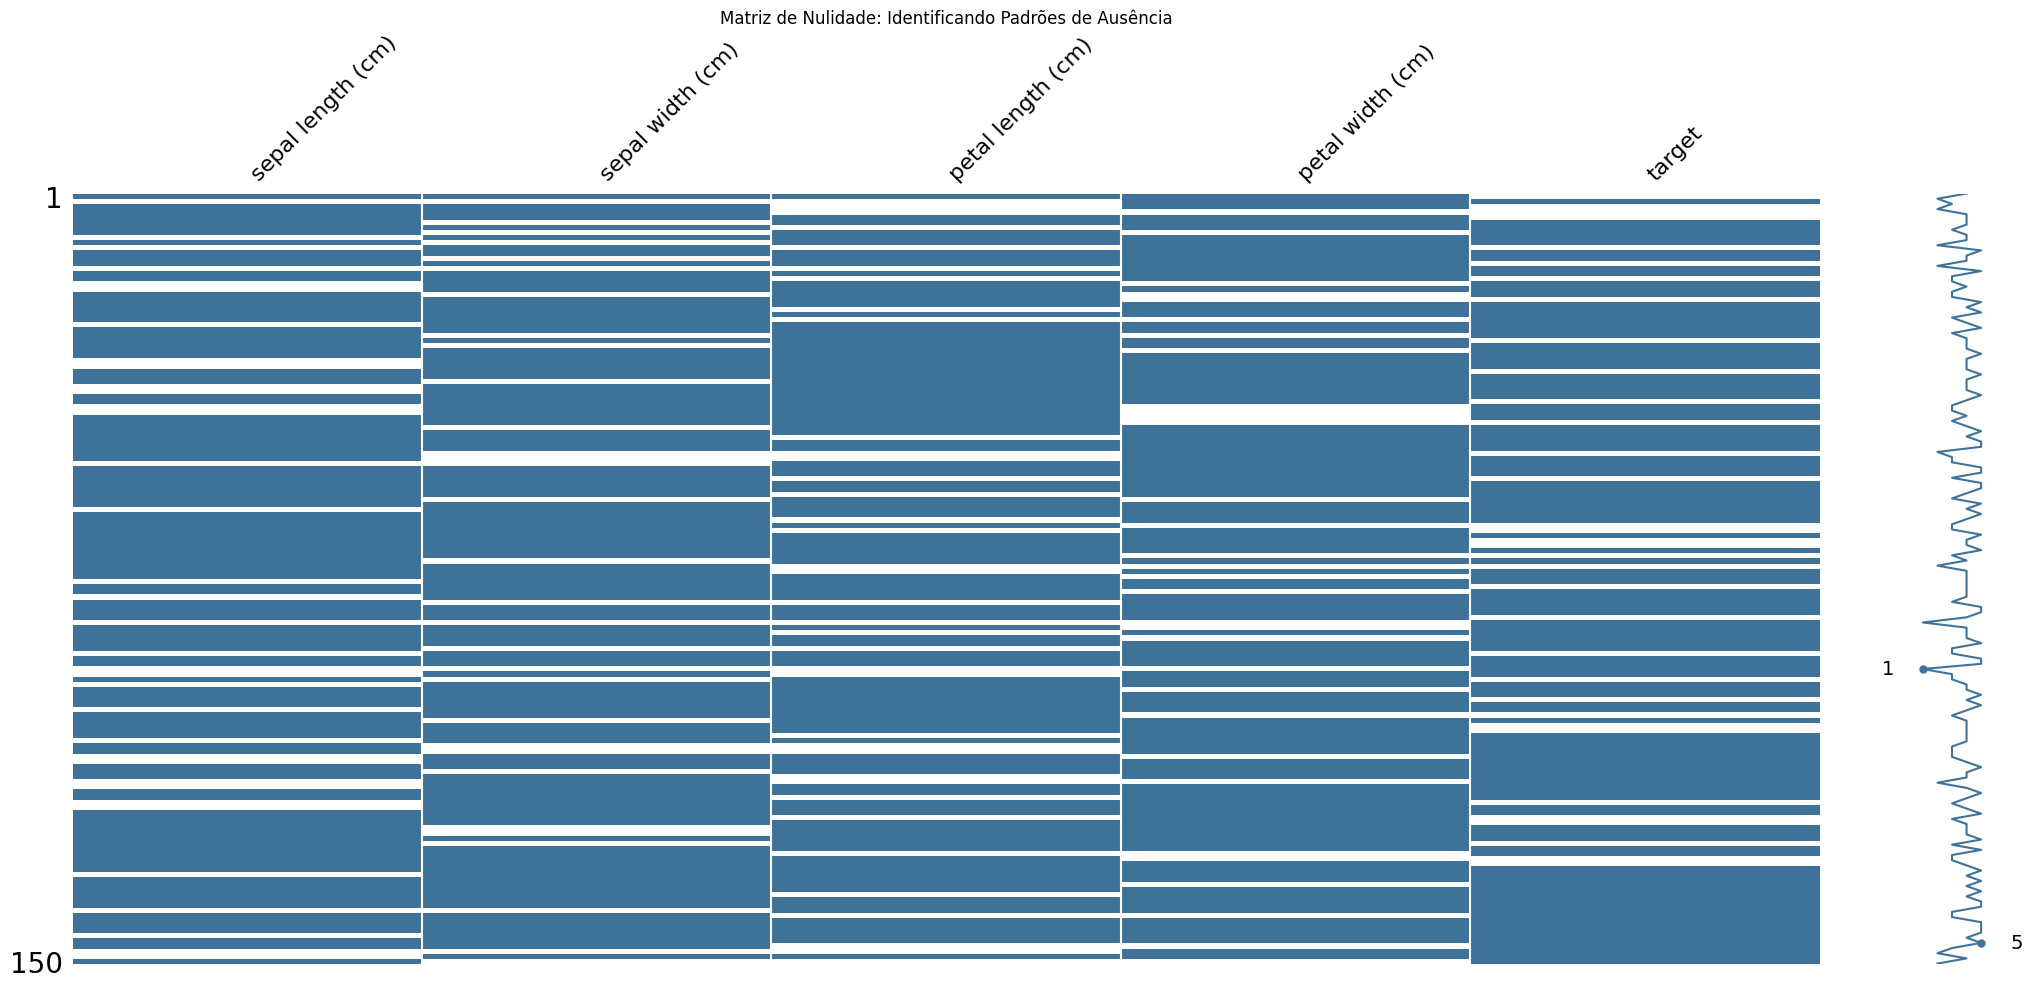

In [25]:
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Recriando o dataframe com os missings para as visualizações e próximas imputações
df_missing = pd.DataFrame(data.data, columns=data.feature_names)
df_missing['target'] = data.target_names[data.target]
df_missing.iloc[:, :-1] = df_missing.iloc[:, :-1].mask(mask_num)
df_missing.loc[mask_cat, 'target'] = np.nan

# Visualizando a topografia da ausência
plt.figure(figsize=(10,6))
msno.matrix(df_missing, color=(0.25, 0.45, 0.6))
plt.title("Matriz de Nulidade: Identificando Padrões de Ausência")
plt.show()


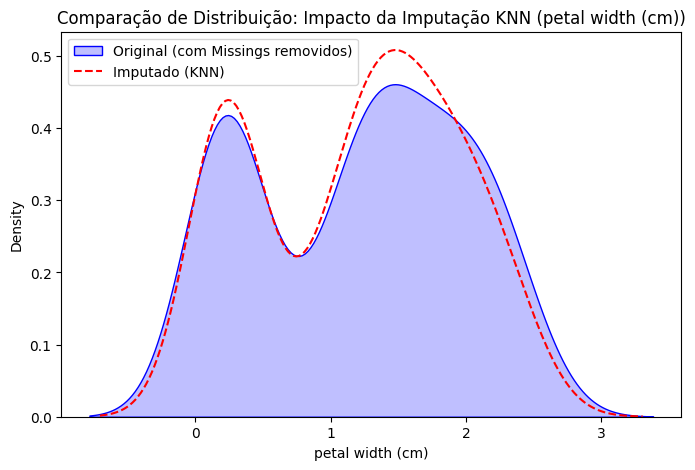

In [34]:
from sklearn.impute import KNNImputer

# Criando um subset numérico para teste
colunas_numericas = df_missing.select_dtypes(include=[np.number]).columns
df_sample = df_missing[colunas_numericas]

# Aplicando KNN Imputer
knn = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(knn.fit_transform(df_sample), columns=df_sample.columns)

# Visualizando o impacto na distribuição de uma das variáveis
col_alvo = colunas_numericas[3]
plt.figure(figsize=(8,5))
sns.kdeplot(df_missing_pre[col_alvo].dropna(), label='Original (com Missings removidos)', color='blue', fill=True)
sns.kdeplot(df_knn[col_alvo], label='Imputado (KNN)', color='red', linestyle='--')
plt.title(f"Comparação de Distribuição: Impacto da Imputação KNN ({col_alvo})")
plt.legend()
plt.show()


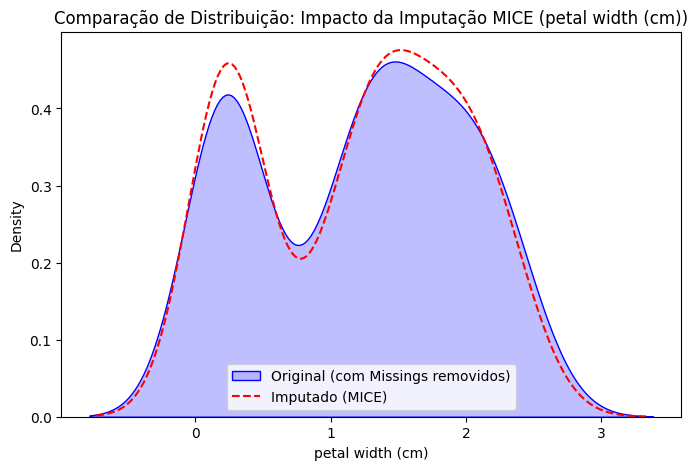

In [35]:
import warnings
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Ignorando avisos de convergência esperados com RandomForest
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.impute')

# Definindo o estimador avançado para capturar não-linearidades
estimator = RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42)

# Configurando o IterativeImputer com mais iterações para garantir a convergência
mice_imputer = IterativeImputer(estimator=estimator, max_iter=50, random_state=42)

# Executando a imputação multivariada
df_mice = pd.DataFrame(mice_imputer.fit_transform(df_sample), columns=df_sample.columns)
df_mice.head()

# Visualizando o impacto na distribuição de uma das variáveis
plt.figure(figsize=(8,5))
sns.kdeplot(df_missing_pre[col_alvo].dropna(), label='Original (com Missings removidos)', color='blue', fill=True)
sns.kdeplot(df_mice[col_alvo], label='Imputado (MICE)', color='red', linestyle='--')
plt.title(f"Comparação de Distribuição: Impacto da Imputação MICE ({col_alvo})")
plt.legend()
plt.show()

In [15]:
import pandas as pd

# 1. Sample text sentences (product/movie reviews)
original_texts = [
    "This product is absolutely great and I love it.",
    "The movie was terrible and a waste of time.",
    "It is a good option for the price.",
    "I had a very bad experience with customer service.",
    "The package arrived on Tuesday.",
    "I feel neutral about this new update."
]

# 2. Simulate missing data by masking key sentiment-bearing words
masked_texts = [
    "This product is absolutely [MASK] and I love it.",
    "The movie was [MASK] and a waste of time.",
    "It is a [MASK] option for the price.",
    "I had a very [MASK] experience with customer service.",
    "The package arrived on Tuesday.",
    "I feel neutral about this new update."
]

# Store in a DataFrame for easier handling and visualization
df_text = pd.DataFrame({
    'original_text': original_texts,
    'masked_text': masked_texts,
    'sentiment': ['positive', 'negative', 'positive', 'negative', 'neutral', 'neutral']
})

df_text

,original_text,masked_text,sentiment
0,This product is absolutely great and I love it.,This product is absolutely [MASK] and I love it.,positive
1,The movie was terrible and a waste of time.,The movie was [MASK] and a waste of time.,negative
2,It is a good option for the price.,It is a [MASK] option for the price.,positive
3,I had a very bad experience with customer serv...,I had a very [MASK] experience with customer s...,negative
4,The package arrived on Tuesday.,The package arrived on Tuesday.,neutral
5,I feel neutral about this new update.,I feel neutral about this new update.,neutral


In [36]:
import warnings
from transformers import pipeline
import pandas as pd

# Suppress UserWarning from huggingface_hub about missing HF_TOKEN
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')

# Initialize the sentiment analysis pipeline with an explicit lightweight model
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')

# Analyze original texts
orig_results = sentiment_analyzer(df_text['original_text'].tolist())
df_text['orig_pred'] = [res['label'] for res in orig_results]
df_text['orig_score'] = [res['score'] for res in orig_results]

# Analyze masked texts
masked_results = sentiment_analyzer(df_text['masked_text'].tolist())
df_text['masked_pred'] = [res['label'] for res in masked_results]
df_text['masked_score'] = [res['score'] for res in masked_results]

# Display the DataFrame to compare
df_text


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,original_text,masked_text,sentiment,orig_pred,orig_score,masked_pred,masked_score
0,This product is absolutely great and I love it.,This product is absolutely [MASK] and I love it.,positive,POSITIVE,0.999882,POSITIVE,0.999881
1,The movie was terrible and a waste of time.,The movie was [MASK] and a waste of time.,negative,NEGATIVE,0.999812,NEGATIVE,0.999813
2,It is a good option for the price.,It is a [MASK] option for the price.,positive,POSITIVE,0.999682,POSITIVE,0.965840
3,I had a very bad experience with customer serv...,I had a very [MASK] experience with customer s...,negative,NEGATIVE,0.999813,POSITIVE,0.968485
4,The package arrived on Tuesday.,The package arrived on Tuesday.,neutral,POSITIVE,0.982957,POSITIVE,0.982957
5,I feel neutral about this new update.,I feel neutral about this new update.,neutral,NEGATIVE,0.998350,NEGATIVE,0.998350


## Criar Base de Dados Complexa (Múltiplos Missings)



In [21]:
import pandas as pd

# 1. Sample text sentences (varied sentiments)
original_complex = [
    "I absolutely loved this incredible new feature, it works perfectly.",
    "The battery life is incredibly short and completely ruins the experience.",
    "It is an okay product, but it lacks some essential functionalities.",
    "The customer support was hostile and refused to help me with the refund.",
    "I am somewhat satisfied with the purchase, though the delivery was late."
]

# 2. Simulate severe missing data by masking multiple key sentiment/context words
masked_complex = [
    "I [MASK] [MASK] this [MASK] new feature, it works [MASK].",
    "The battery life is [MASK] [MASK] and [MASK] ruins the experience.",
    "It is an [MASK] product, but it lacks some [MASK] functionalities.",
    "The customer support was [MASK] and [MASK] to help me with the refund.",
    "I am [MASK] [MASK] with the purchase, though the delivery was [MASK]."
]

# 3. Combine into a DataFrame
df_complex_text = pd.DataFrame({
    'original_text': original_complex,
    'masked_text': masked_complex,
    'true_sentiment': ['positive', 'negative', 'neutral', 'negative', 'neutral']
})

df_complex_text

,original_text,masked_text,true_sentiment
0,I absolutely loved this incredible new feature...,"I [MASK] [MASK] this [MASK] new feature, it wo...",positive
1,The battery life is incredibly short and compl...,The battery life is [MASK] [MASK] and [MASK] r...,negative
2,"It is an okay product, but it lacks some essen...","It is an [MASK] product, but it lacks some [MA...",neutral
3,The customer support was hostile and refused t...,The customer support was [MASK] and [MASK] to ...,negative
4,"I am somewhat satisfied with the purchase, tho...","I am [MASK] [MASK] with the purchase, though t...",neutral


## Análise de Sentimento com Transformer


In [22]:
import warnings
from transformers import pipeline
import pandas as pd

# Suppress UserWarning from huggingface_hub about missing HF_TOKEN
warnings.filterwarnings('ignore', category=UserWarning, module='huggingface_hub')

# Initialize the sentiment analysis pipeline
sentiment_analyzer = pipeline('sentiment-analysis', model='distilbert/distilbert-base-uncased-finetuned-sst-2-english')

# Analyze original texts
orig_complex_results = sentiment_analyzer(df_complex_text['original_text'].tolist())
df_complex_text['orig_pred'] = [res['label'] for res in orig_complex_results]
df_complex_text['orig_score'] = [res['score'] for res in orig_complex_results]

# Analyze masked texts
masked_complex_results = sentiment_analyzer(df_complex_text['masked_text'].tolist())
df_complex_text['masked_pred'] = [res['label'] for res in masked_complex_results]
df_complex_text['masked_score'] = [res['score'] for res in masked_complex_results]

# Display the DataFrame to compare
df_complex_text


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,original_text,masked_text,true_sentiment,orig_pred,orig_score,masked_pred,masked_score
0,I absolutely loved this incredible new feature...,"I [MASK] [MASK] this [MASK] new feature, it wo...",positive,POSITIVE,0.999879,POSITIVE,0.999809
1,The battery life is incredibly short and compl...,The battery life is [MASK] [MASK] and [MASK] r...,negative,NEGATIVE,0.999802,NEGATIVE,0.999751
2,"It is an okay product, but it lacks some essen...","It is an [MASK] product, but it lacks some [MA...",neutral,NEGATIVE,0.996134,NEGATIVE,0.998030
3,The customer support was hostile and refused t...,The customer support was [MASK] and [MASK] to ...,negative,NEGATIVE,0.999643,NEGATIVE,0.769397
4,"I am somewhat satisfied with the purchase, tho...","I am [MASK] [MASK] with the purchase, though t...",neutral,POSITIVE,0.994496,NEGATIVE,0.838726


## Visualizar Impacto e Comparação



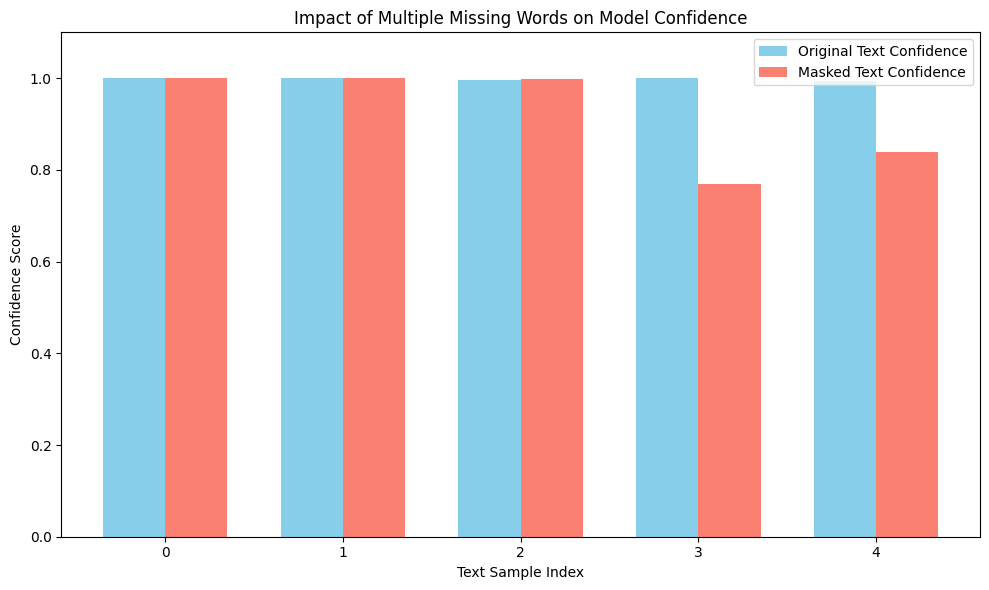

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Define data and labels
indices = np.arange(len(df_complex_text))
width = 0.35
orig_scores = df_complex_text['orig_score']
masked_scores = df_complex_text['masked_score']

# Create the grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(indices - width/2, orig_scores, width, label='Original Text Confidence', color='skyblue')
bars2 = ax.bar(indices + width/2, masked_scores, width, label='Masked Text Confidence', color='salmon')

# Add labels, title, and legend
ax.set_xlabel('Text Sample Index')
ax.set_ylabel('Confidence Score')
ax.set_title('Impact of Multiple Missing Words on Model Confidence')
ax.set_xticks(indices)
ax.set_xticklabels(indices)
ax.set_ylim(0, 1.1)
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()